<a href="https://colab.research.google.com/github/arsingla786/MLFromScratch/blob/main/ChurnPredictionANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [103]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Download latest version
path = kagglehub.dataset_download("rjmanoj/credit-card-customer-churn-prediction")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'credit-card-customer-churn-prediction' dataset.
Path to dataset files: /kaggle/input/credit-card-customer-churn-prediction


In [104]:
import pandas as pd
df = pd.read_csv('/kaggle/input/credit-card-customer-churn-prediction/Churn_Modelling.csv')

In [105]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [106]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [108]:
df.duplicated().sum()

np.int64(0)

In [109]:
df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


In [110]:
df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [111]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [112]:
df = pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)

In [113]:
from sklearn.model_selection import train_test_split
X = df.drop(columns = ['Exited'])
y = df['Exited']

In [114]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [115]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [116]:
X_train.shape

(8000, 11)

In [117]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [118]:
model = Sequential()

model.add(Dense(3,activation='sigmoid',input_dim=11))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [119]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 3)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 40 (160.00 B)

 Non-trainable params: 0 (0.00 B)

In [120]:
model.compile(loss='binary_crossentropy',optimizer='Adam')

In [121]:
model.fit(X_train,y_train,epochs=10)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6932  
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5729
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5179
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4875
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4693
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4573
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4486
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4421
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4371
Epoch 10/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4333


In [122]:
model.layers[0].get_weights()

[array([[ 0.21874596,  0.07893732, -0.05430314],
        [-1.4118928 , -0.93001133,  1.7877008 ],
        [-0.22460344,  0.12092427, -0.05606896],
        [-0.18359041, -0.24444783,  0.33180177],
        [ 0.02357743, -0.04832768, -0.36325306],
        [ 0.42047969, -0.04045043,  0.08093353],
        [-0.05946618,  0.9425219 , -0.17647608],
        [-0.44307724,  0.07996918,  0.08292573],
        [ 0.06870679, -0.5640293 ,  0.44423592],
        [ 0.12551555,  0.02845827,  0.02544475],
        [ 0.14713742,  0.4021749 , -0.37359768]], dtype=float32),
 array([-0.07810894,  0.7525785 , -0.47610337], dtype=float32)]

In [123]:
y_log = model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [124]:
import numpy as np
y_pred = np.where(y_log>0.5,1,0)
from sklearn.metrics import accuracy_score

In [125]:
accuracy_score(y_test , y_pred)

0.816

In [126]:
#to increase accuracy -> try to increase layers, nodes in hidden layers,

In [127]:
model2 = Sequential()

model2.add(Dense(11,activation='relu',input_dim=11))
model2.add(Dense(11,activation='relu'))
model2.add(Dense(1,activation='relu'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [128]:
model2.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [129]:
model2.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [130]:
history = model2.fit(X_train,y_train,epochs=20,validation_split=0.2)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7484 - loss: 1.4943 - val_accuracy: 0.7744 - val_loss: 0.9542
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7773 - loss: 0.8937 - val_accuracy: 0.8019 - val_loss: 0.6306
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7975 - loss: 0.6305 - val_accuracy: 0.8131 - val_loss: 0.4804
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8058 - loss: 0.5309 - val_accuracy: 0.8238 - val_loss: 0.4747
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8122 - loss: 0.5255 - val_accuracy: 0.8075 - val_loss: 0.4984
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8108 - loss: 0.4903 - val_accuracy: 0.8269 - val_loss: 0.4737
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8209 - loss: 0.4773 - val_accuracy: 0.8275 - val_loss: 0.4586
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8211 - loss: 0.4592 - val_accuracy: 0.

In [131]:
y_log2 = model2.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [132]:
y_pred2 = np.where(y_log2>0.5,1,0)

In [133]:
accuracy_score(y_test,y_pred2)

0.8435

In [134]:
import matplotlib.pyplot as plt
history.history

{'accuracy': [0.7484375238418579,
  0.77734375,
  0.7975000143051147,
  0.8057812452316284,
  0.8121874928474426,
  0.8107812404632568,
  0.8209375143051147,
  0.821093738079071,
  0.823437511920929,
  0.8248437643051147,
  0.8298437595367432,
  0.8317187428474426,
  0.8259375095367432,
  0.8304687738418579,
  0.8374999761581421,
  0.8389062285423279,
  0.8409374952316284,
  0.8418750166893005,
  0.8409374952316284,
  0.8428124785423279],
 'loss': [1.4943045377731323,
  0.893700361251831,
  0.6305014491081238,
  0.5308695435523987,
  0.5254983901977539,
  0.4903038740158081,
  0.4773053824901581,
  0.45918795466423035,
  0.45004990696907043,
  0.4504584074020386,
  0.4423525631427765,
  0.44049927592277527,
  0.43257904052734375,
  0.4264782667160034,
  0.4074983298778534,
  0.4065222442150116,
  0.40225687623023987,
  0.4069962203502655,
  0.4056122303009033,
  0.4000908136367798],
 'val_accuracy': [0.7743750214576721,
  0.8018749952316284,
  0.8131250143051147,
  0.8237500190734863,


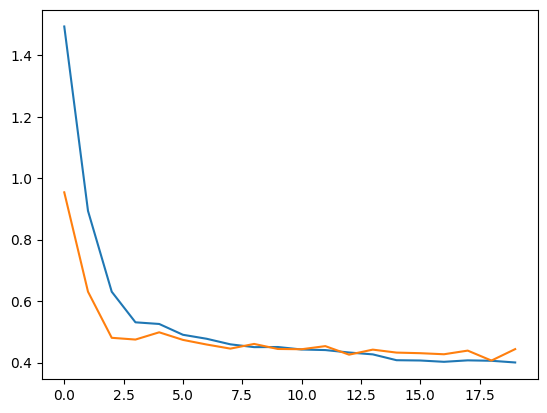

In [135]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

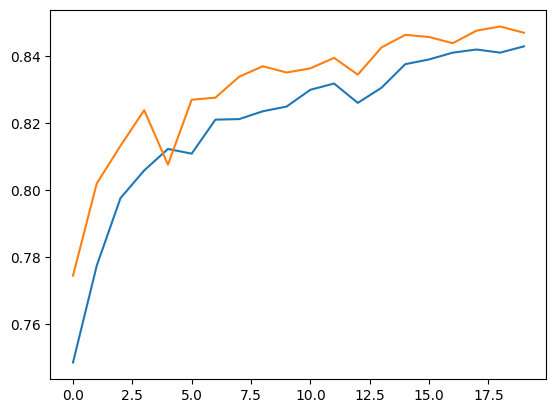

In [136]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])  #not much gap means there is no overfitting